<a href="https://colab.research.google.com/github/joonookwak/Deep-Generative-Models-Practice/blob/main/VAE_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch # 딥러닝
import torch.nn as nn # Neural Network 층, 손실함수
import torch.optim as optim # 최적화 도구 : 경사하강법,모멘텀...
from torch.utils.data import DataLoader # 문제 묶음을 학습 루프에 하나씩 예쁘게 던져주는 '서빙' 역할
from torchvision import datasets, transforms
import matplotlib.pyplot as plt # 시각화도구

# GPU 사용 가능한지 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 장치: {device}")

현재 사용 중인 장치: cuda


In [ ]:
# 이미지 데이터를 숫자로 바꾸고 정규화하는 과정 (Transform). 전처리 과정.
transform = transforms.Compose([
    transforms.ToTensor(), # ToTensor : 이미지 데이터는 원래 0~255 사이의 픽셀 값인데, 이걸 0.0~1.0 사이의 소수점으로 바꾸고(정규화) 텐서(Tensor, 다차원 행렬) 형태(파이토치가 연산할 수 있는 형태)로 변환해 주는 작업
])

# 데이터 다운로드 및 로드 (MNIST : 사람들이 직접 쓴 0부터 9까지의 손글씨 숫자 이미지 모음집 60000장 가로x세로=28픽셀x28픽셀)
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

# 배치 사이즈 설정 (교수님이 강조하신 부분!)
batch_size = 64 # 한 번에 64개씩 묶어서 공부(SGD)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
#재구축
class VAE(nn.Module): #파이토치에서 딥러닝 모델을 만들 때는 항상 이 nn.Module이라는 기본 뼈대를 상속받아서 시작. VAE : 잠재공간의 연속성을 보장한다는 점에서 AE의 상위버전.
    # Encoder 설계
    def __init__(self):
        super(VAE, self).__init__()

        # 1. Encoder 부분: 28x28 이미지를 입력받음 --> 784개의 픽셀을 다 보는게 힘드니깐 핵심특징(z) 20개만 보자. #400,20 숫자는 하이퍼파라미터.
        self.fc1 = nn.Linear(784, 400) # 입력층 (28*28=784) fc: fully connected layer.
        self.fc2_mu = nn.Linear(400, 20)  # 평균(mu)을 구하는 층 (20차원으로 압축)
        self.fc2_logvar = nn.Linear(400, 20) # 분산(log variance)을 구하는 층
        # 평균, 분산을 구하는 식은 없다. 그저 이름표만 mu, logvar라고 붙여주고, Loss 함수로 "이 숫자들은 평균과 분산처럼 행동해야 해!"라고 압박(패널티)만 줬을 뿐. 그럼 알아서 학습해서 뽑아낸다.

        # 2. Decoder 부분
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = torch.relu(self.fc1(x)) # 활성화 함수 사용
        return self.fc2_mu(h1), self.fc2_logvar(h1)


    # 재파라미터화 트릭(Reparameterization Trick) : 샘플링 과정에서의 무작위성을 배제하여 역전파 가능하게 함.
    def reparameterize(self, mu, logvar):
        # 1. 표준편차(std) 구하기
        # 딥러닝은 분산이 마이너스가 되는 걸 막기 위해 '로그 분산(logvar)'을 출력합니다.
        # 이걸 다시 원래의 표준편차로 되돌리는 수학 공식입니다.
        std = torch.exp(0.5 * logvar)

        # 2. 엡실론(eps) 주사위 굴리기
        # std와 똑같은 크기를 가진, 정규분포(평균 0, 분산 1) 난수를 생성합니다.
        eps = torch.randn_like(std)

        # 3. 최종 z 조립하기 (트릭 공식 적용!) --> 784개의 픽셀을 다 보는게 힘드니깐 핵심특징(z) 20개만 보자
        return mu + eps * std


    # Decoder 설계
    def decode(self, z):
        h3 = torch.relu(self.fc3(z))
        # 마지막엔 ReLU 대신 Sigmoid를 씁니다! (매우 중요) : ToTensor로 0~1로 바꿨었기 때문에 같은 형식으로 출력하기 위함
        return torch.sigmoid(self.fc4(h3))

    # 전체 흐름을 지휘하는 forward 함수
    def forward(self, x):
        # 1. 28x28 이미지를 784 한 줄로 쫙 펴서 넣고 평균/분산 압축 (Encode)
        mu, logvar = self.encode(x.view(-1, 784))

        # 2. 트릭을 써서 핵심 유전자 z 뽑기 (Reparameterize)
        z = self.reparameterize(mu, logvar)

        # 3. z를 다시 784픽셀 이미지로 복원하기 (Decode)
        return self.decode(z), mu, logvar


In [ ]:
import torch.nn.functional as F

# VAE 전용 특수 Loss 함수
def loss_function(recon_x, x, mu, logvar):

    # 1. 재구축 오차 (Reconstruction Loss)
    # 원본 이미지(x)와 모델이 복원한 이미지(recon_x)의 픽셀 차이를 계산합니다.
    # reduction='sum'은 배치(64개) 안에 있는 모든 픽셀의 오차를 싹 다 더하라는 뜻입니다.
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # 2. KL Divergence (KLD) : VAE를 '생성형 AI'로 만들어주는 핵심 마법. N(0,1) 모양으로 예쁘게 뭉쳐놓으라고 강제하는 패널티(벌점).
    # 모델이 만든 평균(mu)과 분산(logvar)이, 우리가 원하는 예쁜 '표준 정규분포'와
    # 얼마나 동떨어져 있는지 계산하는 수학 공식입니다.
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # 3. 최종 오차 = 두 가지 오차의 합!
    # 교수님이 "Propose a new loss function"을 해보라고 하셨죠? 나중에 프로젝트를 할 때 이 BCE와 KLD 앞에 **가중치(β)**를 곱해서 비율을 조절해 볼 수 있습니다. (이걸 Beta-VAE라고 부릅니다!)
    return BCE + KLD

In [ ]:
# 1. 모델과 최적화 도구 준비
model = VAE().to(device) # 우리가 만든 VAE 모델을 GPU로 보냅니다!
# 강의에서 배운 SGD 대신, 모멘텀 기능이 업그레이드된 'Adam'이라는 최적화 도구를 씁니다.
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10 # 전체 데이터셋을 10번 반복해서 공부하겠다는 뜻 (iteration)

# 모델을 '학습 모드'로 전환
model.train()

print("🚀 학습을 시작합니다!")

for epoch in range(epochs):
    train_loss = 0

    # 2. 배치(64개) 단위로 데이터 꺼내오기
    # (data, _) 에서 '_'는 정답 라벨(0~9)입니다.
    # VAE는 자기가 자기자신을 복원하는 거라 정답 라벨이 필요 없습니다! (비지도 학습)
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device) # 데이터도 GPU로 보냄

        # --- 딥러닝의 핵심 5단계 ---

        # 단계 1. 이전 기울기 초기화 (도화지 지우기). 까먹고 실수 많이 하는 구간
        optimizer.zero_grad()

        # 단계 2. 순전파 (데이터를 모델에 통과시키기)
        recon_batch, mu, logvar = model(data)

        # 단계 3. 오차 계산 (얼마나 틀렸는지 채점)
        loss = loss_function(recon_batch, data, mu, logvar)

        # 단계 4. 역전파 (오차를 거꾸로 흘려보내며 기울기 계산)
        loss.backward()

        # 단계 5. 가중치 업데이트 (계산된 기울기 방향으로 한 걸음 이동!)
        optimizer.step()

        train_loss += loss.item()

    # 한 Epoch가 끝날 때마다 평균 오차 출력
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'====> Epoch: {epoch+1:02d} | Average loss: {avg_loss:.4f}')

🚀 학습을 시작합니다!
====> Epoch: 01 | Average loss: 147.3812
====> Epoch: 02 | Average loss: 115.7098
====> Epoch: 03 | Average loss: 111.2290
====> Epoch: 04 | Average loss: 109.1280
====> Epoch: 05 | Average loss: 107.9488
====> Epoch: 06 | Average loss: 107.1297
====> Epoch: 07 | Average loss: 106.4909
====> Epoch: 08 | Average loss: 106.0548
====> Epoch: 09 | Average loss: 105.6125
====> Epoch: 10 | Average loss: 105.2981


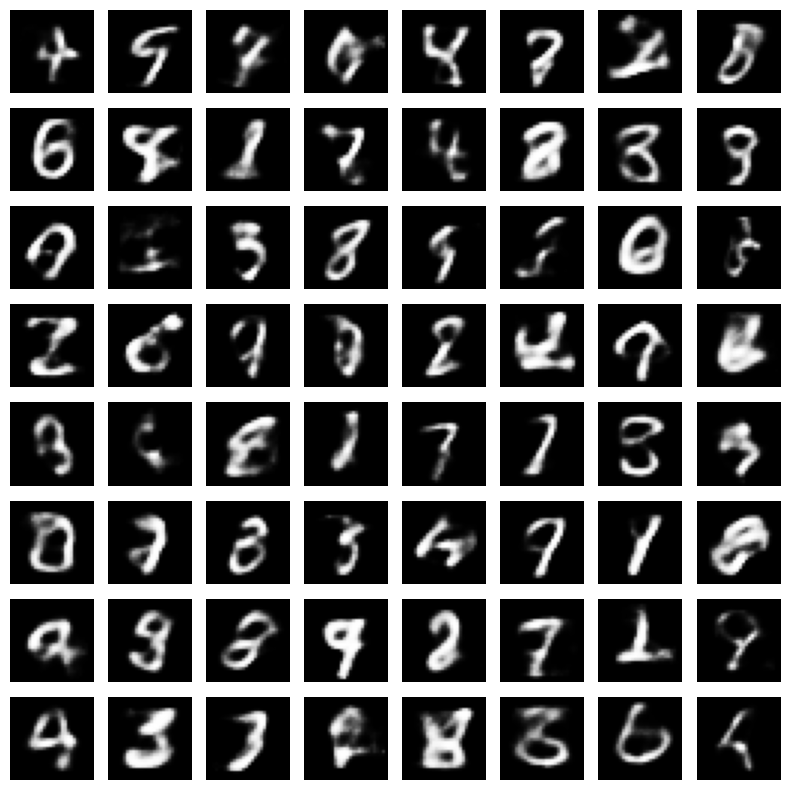

In [ ]:
# 생성형 AI. 역전파(기울기 계산)를 안 할 거니까 엔진을 잠깐 끕니다. (메모리 절약)
with torch.no_grad():

    # 1. 무작위 유전자(z) 생성: 64개의 가짜 데이터를 위해 20차원의 난수를 굴립니다!
    # 여기가 바로 교수님이 말씀하신 'Generative AI'의 시작점입니다.
    sample_z = torch.randn(64, 20).to(device)

    # 2. 모델의 복원기(Decoder)에 가짜 유전자를 넣어서 64장의 이미지를 상상해내게 합니다.
    generated_images = model.decode(sample_z).cpu()

# 3. 모델이 상상해낸 64장의 숫자 이미지를 예쁘게 그림으로 그립니다.
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    # 784개의 긴 픽셀 줄을 다시 28x28 네모난 이미지로 접어줍니다.
    ax.imshow(generated_images[i].view(28, 28), cmap='gray')
    ax.axis('off') # 지저분한 축(axis) 눈금은 가려줍니다.

plt.tight_layout()
plt.show()

VAE는 안정적으로 학습되지만 결과물이 흐릿한 한계가 있다.

BCE=−∑[ylog( y ^ ​ )+(1−y)log(1− y ^ ​ )]
왜 MSE(평균 제곱 오차) 안 쓰고 이걸 쓸까요?
분류 문제나 픽셀값이 0~1 사이일 때, 모델이 정답과 **완전히 정반대의 헛소리(예: 하얀색인데 0%라고 우길 때)**를 하면, MSE는 벌점을 그냥 "음, 1만큼 틀렸네" 하고 부드럽게 주지만, BCE는 벌점을 '무한대'로 줘서 모델의 뺨을 아주 매섭게 때려버립니다. 그래서 학습이 훨씬 빠르고 강력하게 일어나는 거죠!

In [ ]:
# 잠재 공간 탐험
# 기존 VAE와 헷갈리지 않게 이름을 VAE_2D로 변경!
class VAE_2D(nn.Module):
    def __init__(self):
        super(VAE_2D, self).__init__()

        self.fc1 = nn.Linear(784, 400)
        # ⭐️ 20차원 -> 2차원으로 극단적 압축!
        self.fc2_mu = nn.Linear(400, 2)
        self.fc2_logvar = nn.Linear(400, 2)

        # ⭐️ 다시 2차원에서 400차원으로 복원 시작
        self.fc3 = nn.Linear(2, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = torch.relu(self.fc1(x))
        return self.fc2_mu(h1), self.fc2_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [ ]:
# 1. 2차원 모델을 GPU에 올리고, 새로운 최적화 도구 연결
model_2d = VAE_2D().to(device)
optimizer_2d = optim.Adam(model_2d.parameters(), lr=1e-3)

epochs = 10
model_2d.train()

print("🚀 2차원 VAE 학습을 시작합니다!")

for epoch in range(epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        optimizer_2d.zero_grad()
        recon_batch, mu, logvar = model_2d(data)

        # Loss 함수는 아까 만들어둔 걸 그대로 씁니다!
        loss = loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        optimizer_2d.step()
        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader.dataset)
    print(f'====> Epoch: {epoch+1:02d} | Average loss: {avg_loss:.4f}')

🚀 2차원 VAE 학습을 시작합니다!
====> Epoch: 01 | Average loss: 179.7653
====> Epoch: 02 | Average loss: 163.8661
====> Epoch: 03 | Average loss: 160.7181
====> Epoch: 04 | Average loss: 158.8324
====> Epoch: 05 | Average loss: 157.5096
====> Epoch: 06 | Average loss: 156.4597
====> Epoch: 07 | Average loss: 155.5711
====> Epoch: 08 | Average loss: 154.7935
====> Epoch: 09 | Average loss: 153.9791
====> Epoch: 10 | Average loss: 153.2603


극단적인 압축으로 복원 오차가 커졌지만, 2차원 시각화가 가능해짐. 20차원은 눈으로 못보잖아

-->

실제 연구에서는 지도를 보자고 모델의 성능을 2차원으로 망치지 않습니다. 대신, 모델은 똑똑하게 20차원(혹은 100차원)으로 훈련시켜서 최고 성능을 뽑아낸 다음, 시각화를 할 때만 특수한 수학적 **그림자 놀이 기법(t-SNE 또는 UMAP)**을 사용해 2차원 도화지에 투영시킵니다.

/tmp/ipykernel_1503/3319625657.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  figure[i * digit_size: (i + 1) * digit_size,


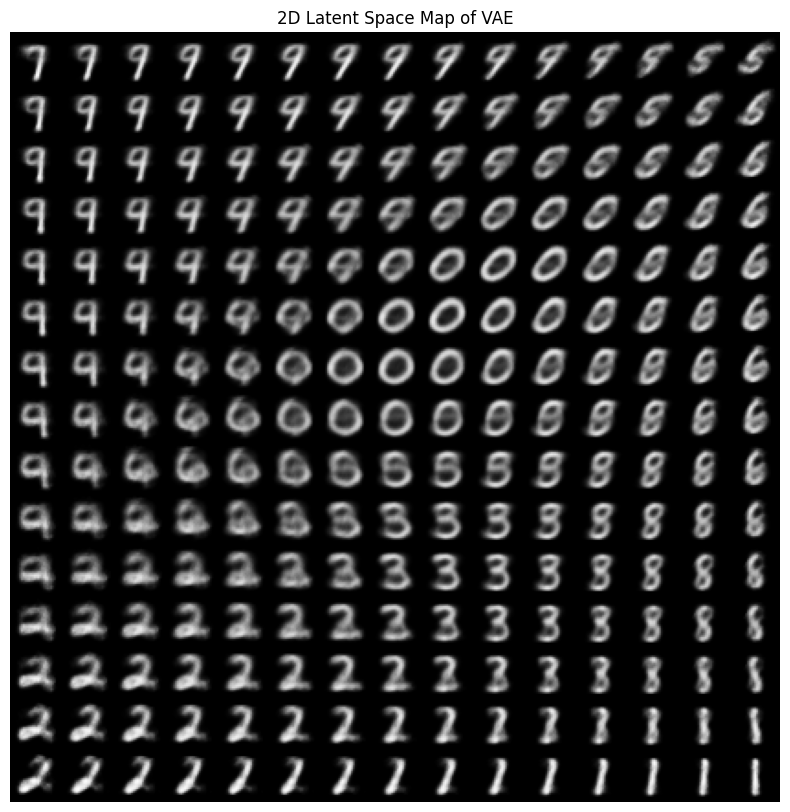

In [ ]:
# VAE가 학습한 **'인공지능의 머릿속 2차원 지도'**를 눈앞에 펼쳐주는 아주 마법 같은 코드
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import torch

# 지도의 크기와 해상도 설정 (15x15 격자로 총 225개의 숫자 상상하기, 각 숫자는 28픽셀x28픽셀)
n = 15
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# x축, y축 좌표를 정규분포(확률)에 맞게 촘촘하게 쪼갭니다.
# (-3부터 3까지의 범위가 모델이 학습한 2차원 뇌의 주요 공간입니다--> KLD에서 정규분포와 가깝게 추정했기에, norm함수로 5%~95% 안 구간만 효율적으로 스캔)
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))

model_2d.eval() # ⭐️ 2차원 모델 평가 모드로 전환!
with torch.no_grad():
    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            # 2차원 좌표 [xi, yi]를 모델의 Decoder에 던져줍니다!
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            x_decoded = model_2d.decode(z_sample).cpu()

            # 상상해낸 이미지를 거대한 도화지(figure)의 제자리에 끼워 넣습니다.
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

# 예쁘게 출력하기
plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray')
plt.axis('off')
plt.title("2D Latent Space Map of VAE")
plt.show()

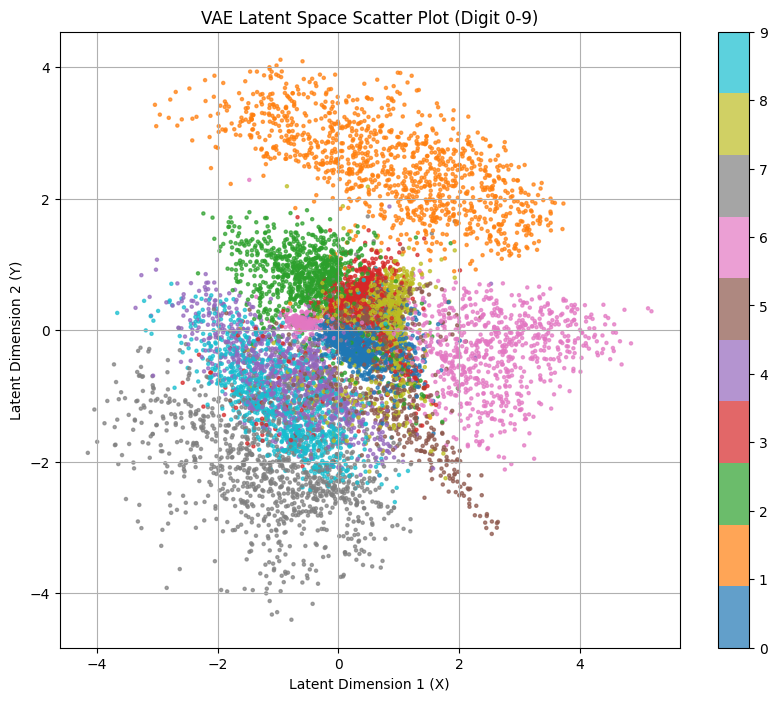

In [ ]:
# 잠재공간(Latent Space) 산점도
# 1. 빈 리스트 준비 (x좌표, y좌표, 실제 정답 색깔)
latent_x = []
latent_y = []
labels = []

model_2d.eval() # 평가 모드 유지
with torch.no_grad():
    # 2. 데이터를 묶음(배치) 단위로 꺼내옵니다.
    for data, label in train_loader:
        data = data.to(device)

        # 3. 핵심! Decoder는 안 쓰고 Encoder만 써서 평균(mu) 좌표만 쏙 빼옵니다.
        mu, logvar = model_2d.encode(data.view(-1, 784))

        # 4. 뽑아낸 좌표와 정답(0~9)을 리스트에 저장합니다.
        latent_x.extend(mu[:, 0].cpu().numpy())
        latent_y.extend(mu[:, 1].cpu().numpy())
        labels.extend(label.numpy())

        # 너무 많으면 복잡하니까 딱 1만 개만 찍어볼게요!
        if len(latent_x) > 10000:
            break

# 5. 멋진 산점도(Scatter Plot) 그리기
plt.figure(figsize=(10, 8))
# c=labels로 정답(0~9)마다 다른 색깔을 칠해줍니다. cmap='tab10'은 10가지 예쁜 색상표!
scatter = plt.scatter(latent_x, latent_y, c=labels, cmap='tab10', alpha=0.7, s=5)

# 옆에 색깔별 숫자 범례(Colorbar) 달아주기
plt.colorbar(scatter, ticks=range(10))
plt.title("VAE Latent Space Scatter Plot (Digit 0-9)")
plt.xlabel("Latent Dimension 1 (X)")
plt.ylabel("Latent Dimension 2 (Y)")
plt.grid(True)
plt.show()

#인공지능이 세상의 이치를 스스로 깨달았다는 증거
1. "누가 가르쳐주지도 않았는데 끼리끼리 모였네?" (Clustering)

우리는 모델에게 "0은 여기 두고, 1은 저기 둬!"라고 가르친 적이 단 한 번도 없습니다. 그저 "복원 잘해!"(BCE)와 "가운데로 뭉쳐!"(KLD)라는 두 가지 Loss만 줬을 뿐이죠.

그런데 그래프를 보면 같은 색깔(같은 숫자)의 점들끼리 자기들만의 '영역(땅)'을 만들어서 예쁘게 모여 있을 겁니다. AI가 숫자들의 형태적 특징을 스스로 분류해 낸 것이죠!

2. "너네 둘은 왜 그렇게 붙어있어?" (Similarity)

그래프에서 유독 색깔이 마구 섞여서 겹쳐 있는 부분들이 있을 겁니다.

예를 들어, 4(보라색쯤)와 9(하늘색쯤), 혹은 3과 8의 경계선을 유심히 보세요. 사람이 흘려 쓰면 4인지 9인지 헷갈리듯이, AI의 뇌 속에서도 이 둘의 '유전자(특징)'가 아주 비슷하게 자리 잡고 있다는 뜻입니다.